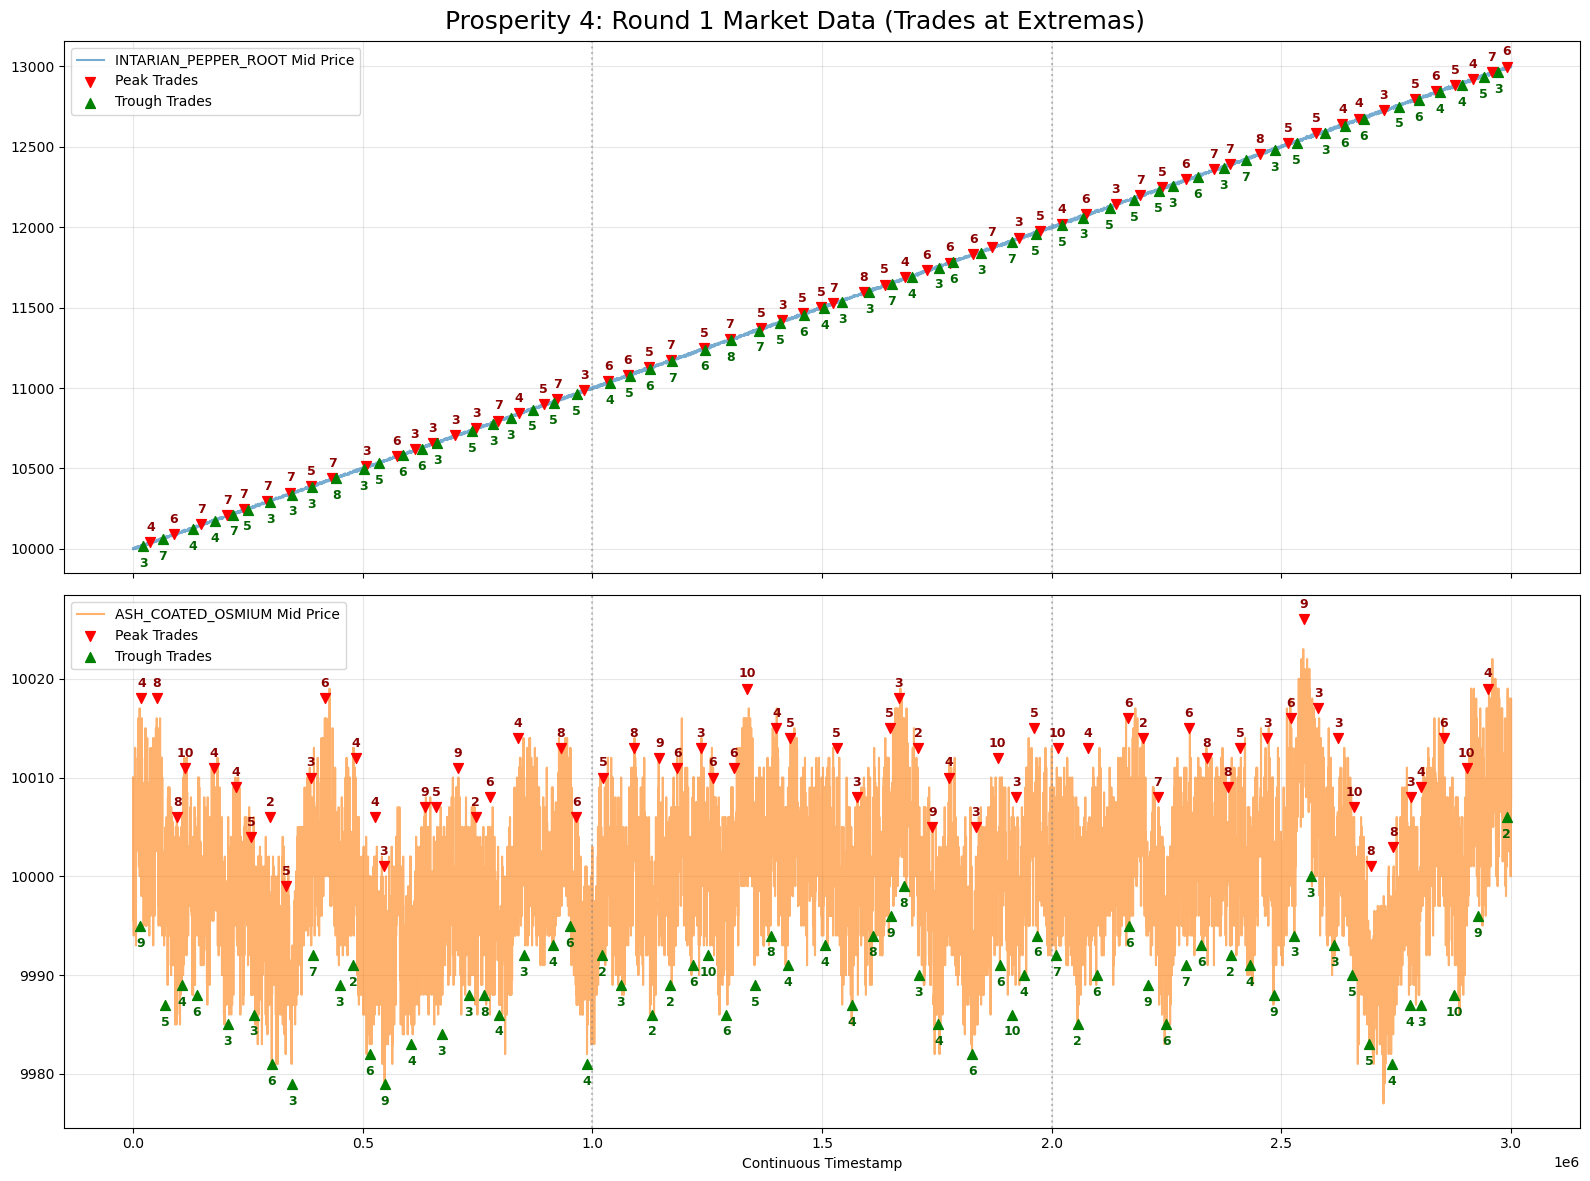

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import os
from scipy.signal import find_peaks

# 1. Define the path to your Round 1 data folder
data_folder = "/home/chesy/Projects/prosperity/prosperity-playground/data/round2/"

# 2. We will stitch these days together
days = [-2, -1, 0]
all_prices = []
all_trades = []

# 3. Load and offset the timestamps
for i, day in enumerate(days):
    price_file = f"{data_folder}/prices_round_1_day_{day}.csv"
    trade_file = f"{data_folder}/trades_round_1_day_{day}.csv"
    
    time_offset = i * 1000000 
    
    # Load Prices
    if os.path.exists(price_file):
        df_price = pd.read_csv(price_file, sep=";")
        df_price['timestamp'] += time_offset
        all_prices.append(df_price)
        
    # Load Trades
    if os.path.exists(trade_file):
        df_trade = pd.read_csv(trade_file, sep=";")
        df_trade['timestamp'] += time_offset
        all_trades.append(df_trade)

# Combine the lists into massive dataframes
if len(all_prices) == 0:
    print("Error: No price files found! Check your data_folder path and day numbers.")
else:
    df_prices_full = pd.concat(all_prices, ignore_index=True)
    df_trades_full = pd.concat(all_trades, ignore_index=True) if all_trades else pd.DataFrame()

    # --- FILTER OUT 0 VALUES ---
    df_prices_full = df_prices_full[df_prices_full['mid_price'] != 0]
    
    if not df_trades_full.empty:
        df_trades_full = df_trades_full[df_trades_full['price'] != 0]

    # --- DYNAMIC PLOTTING ---
    products = df_prices_full['product'].unique()
    num_products = len(products)

    fig, axes = plt.subplots(num_products, 1, figsize=(16, 6 * num_products), sharex=True)
    fig.suptitle('Prosperity 4: Round 1 Market Data (Trades at Extremas)', fontsize=18)

    if num_products == 1:
        axes = [axes]

    # Loop through each product and draw its plot
    for i, product in enumerate(products):
        ax = axes[i]
        prod_data = df_prices_full[df_prices_full['product'] == product].copy()
        
        # Plot Mid Price on the left Y-axis
        ax.plot(prod_data['timestamp'], prod_data['mid_price'], 
                label=f'{product} Mid Price', linewidth=1.5, color='C'+str(i), alpha=0.6)
        
        # Add Trades Book Data at Extremas
        if not df_trades_full.empty:
            prod_trades = df_trades_full[df_trades_full['symbol'] == product].copy()
            
            if not prod_trades.empty:
                # Sort by timestamp to ensure peak finding works correctly
                prod_trades = prod_trades.sort_values('timestamp').reset_index(drop=True)
                prices = prod_trades['price'].values
                
                # Find Peaks (Local Maxima) and Troughs (Local Minima)
                # 'distance' ensures we only pick the most prominent extrema within an X-trade window
                peaks, _ = find_peaks(prices, distance=15)
                troughs, _ = find_peaks(-prices, distance=15)
                
                peak_trades = prod_trades.iloc[peaks]
                trough_trades = prod_trades.iloc[troughs]
                
                # 1. Plot Peaks
                ax.scatter(peak_trades['timestamp'], peak_trades['price'], 
                           color='red', marker='v', s=50, label='Peak Trades', zorder=5)
                
                # Annotate quantities for peaks (text sits above the marker)
                for _, row in peak_trades.iterrows():
                    ax.annotate(f"{int(row['quantity'])}", 
                                (row['timestamp'], row['price']),
                                textcoords="offset points", 
                                xytext=(0, 8), 
                                ha='center', fontsize=9, color='darkred', weight='bold')

                # 2. Plot Troughs
                ax.scatter(trough_trades['timestamp'], trough_trades['price'], 
                           color='green', marker='^', s=50, label='Trough Trades', zorder=5)
                
                # Annotate quantities for troughs (text sits below the marker)
                for _, row in trough_trades.iterrows():
                    ax.annotate(f"{int(row['quantity'])}", 
                                (row['timestamp'], row['price']),
                                textcoords="offset points", 
                                xytext=(0, -15), 
                                ha='center', fontsize=9, color='darkgreen', weight='bold')

        ax.grid(True, alpha=0.3)
        ax.legend(loc='upper left')

        # Vertical lines for day changes
        for offset in [1000000, 2000000]:
            ax.axvline(offset, color='gray', linestyle=':', alpha=0.5)

    plt.xlabel('Continuous Timestamp')
    plt.tight_layout()
    plt.show()